# 보완 및 진행 상황 정리

## 1. XGBClassifier 메인 모델 구축 완료

- 기존 랜덤분리 대신 시간 기준 분리를 적용함
- train: 2021.01 ~ 2023.12
- test: 2024.01 ~ 2026.02
- 과거 데이터로 학습하고 이후 시점의 사고위험을 예측하는 구조라 공모전 취지에 더 적합함

## 2. 하이퍼파라미터 튜닝 완료

- RandomizedSearchCV를 적용하여 XGBoost 하이퍼파라미터 최적값을 탐색함
- 3-fold 교차검증 기준 Best CV ROC-AUC = 0.9030

최적 모델 기준 test 성능은 다음과 같음.

- Recall = 0.8515
- ROC-AUC = 0.9008
- PR-AUC = 0.0659
- F1-score = 0.0793

## 3. Top-K Recall 분석 완료

- 위험도 상위 구간 안에 실제 사고가 얼마나 포함되는지 확인함

- Top 5% Recall = 0.3267
- Top 10% Recall = 0.6007
- Top 20% Recall = 0.8515

즉, 위험도 상위 20% 구간만 집중 관리해도 이후 실제 사고의 약 85.1%를 포함할 수 있음.  
따라서 제한된 안전관리 자원을 어디에 우선 배치할지 결정하는 정책적 근거로 활용 가능함.

## 4. Risk Score 및 위험유형 도출 완료

- XGBoost 예측확률을 0~100점 Risk Score로 변환함
- 역·호선·시간대별 위험도 순위를 생성함
- 각 구간의 주요 지수를 기준으로 위험유형을 분류함

위험유형은 다음과 같이 설정함.

- 환승형
- 구조형
- 유입형
- 혼잡형

## 5. 아직 추가하면 좋은 것

## 비교 모델 2개 돌리기

XGBClassifier만 사용하는 것보다 아래 모델들을 함께 비교하면 최종 모델 선정 근거가 더 강해짐.

- Logistic Regression
- RandomForest
- XGBClassifier

이를 통해 XGBClassifier가 가장 적합했다는 근거를 만들 수 있음.

## Threshold별 성능 비교

현재는 threshold 0.5 기준으로 사고발생 여부를 판단했지만, 정책 목적상 사고위험 구간을 놓치지 않는 것이 중요하므로 threshold별 성능 비교가 필요함.

비교할 threshold는 다음과 같음.

- 0.3
- 0.4
- 0.5
- 0.6
- 0.7

이를 통해 Recall을 우선 고려하여 위험 기준을 설정했다는 설명이 가능함.

## 선택 보완

시간이 있으면 아래 작업까지 추가하면 보고서 완성도가 더 높아짐.

- SHAP 분석
- 지도 시각화
- 최종 결과 CSV 저장

## 최종 방향

현재 XGBClassifier는 메인 모델로 가져가도 충분함.  
시간 기준 분리에서도 Recall 0.8515, ROC-AUC 0.9008로 나타났고, Top 20% Recall도 0.8515로 확인됨.  
따라서 단순 사고/비사고 분류기보다는 Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함.

다만 최종 보고서 설득력을 높이기 위해 비교모델과 threshold 분석은 추가하는 것이 좋음.  
앙상블은 현재 단계에서는 필수 아님.

# 민영 추가
- XGBClassifier 돌릴때 하이퍼파라미터 최적값 찾는 코드 넣으면 어떨지 -> 넣었음
- 마지막 코드에서 혼잡지수가 왜 1.369633e-01 형태로 나오지?? -> 괜찮은거였음
- 로지스틱, 랜덤포레스트는 낼 우리 만나서 같이 돌려보자 -> 오키

# 기본

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 라이브러리 설치
!pip install xgboost -q

In [4]:
# 라이브러리
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [5]:
# csv 파일 불러오기
file_path = '/content/drive/MyDrive/서울시 빅데이터 공모전/data/processed/df_final_all_preprocessed.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
df.head()

,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


In [6]:
# 데이터 기본 확인
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())
df.head()

(73964, 15)
['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량']
사용월               0
호선명               0
time_group        0
혼잡                0
역명_clean          0
구조평균              0
구조최소              0
구조최대              0
사고수               0
유입                0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
환승량               0
dtype: int64


,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


# 사고수 -> 사고발생 여부로 변환

In [7]:
# 사고발생 여부 타깃 변수 생성
# 사고수 > 0 이면 실제 사고가 발생한 경우이므로 1
# 사고수 = 0 이면 사고가 발생하지 않은 경우이므로 0
# 즉, 사고 "건수" 예측이 아니라 사고 "발생 여부"를 예측하는 이진분류 문제로 변환

df['사고발생'] = (df['사고수'] > 0).astype(int)

# 사고발생/미발생 데이터 개수 확인
print(df['사고발생'].value_counts())

# 사고발생/미발생 비율 확인
# 클래스 불균형 정도를 확인하기 위한 단계
print(df['사고발생'].value_counts(normalize=True))

사고발생
0    73152
1      812
Name: count, dtype: int64
사고발생
0    0.989022
1    0.010978
Name: proportion, dtype: float64


In [8]:
# 컬럼명 확인
print(df.columns.tolist())

['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량', '사고발생']


In [9]:
# 숫자형 변수 전처리
# 모델 학습에 사용할 주요 변수들을 숫자형으로 변환하는 단계
# CSV를 불러오면 숫자가 문자열로 들어오거나, 쉼표(,)가 포함되어 있을 수 있기 때문에 정리 필요

num_cols = [
    '혼잡', '유입', '구조평균', '구조최소', '구조최대',
    '환승량',
    'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum'
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                         # 문자열로 변환
        .str.replace(',', '', regex=False)   # 숫자 안의 쉼표 제거
        .str.strip()                         # 앞뒤 공백 제거
    )

    # 숫자로 변환
    # 변환이 안 되는 값은 NaN으로 처리
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 변환 과정에서 생긴 결측치 NaN을 각 컬럼의 중앙값으로 대체
# 평균보다 중앙값이 이상치 영향을 덜 받아서 안전함
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 결측치가 남아 있는지 확인
print(df[num_cols].isna().sum())

혼잡                0
유입                0
구조평균              0
구조최소              0
구조최대              0
환승량               0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
dtype: int64


In [10]:
# 지수 변수 생성
# 혼잡, 유입, 구조, 환승량은 단위와 크기가 서로 다르기 때문에
# 모델이 비교하기 쉽도록 0~1 범위의 지수로 정규화하는 단계

# 혼잡 값 중 비정상적으로 큰 이상값은 NaN으로 처리
df.loc[df['혼잡'] > 10_000_000, '혼잡'] = np.nan

# 이상값 처리로 생긴 결측치는 중앙값으로 대체
df['혼잡'] = df['혼잡'].fillna(df['혼잡'].median())

# 각 변수를 최댓값으로 나누어 0~1 범위의 지수로 변환
df['혼잡지수'] = df['혼잡'] / df['혼잡'].max()
df['유입지수'] = df['유입'] / df['유입'].max()
df['구조지수'] = df['구조최대'] / df['구조최대'].max()
df['환승지수'] = df['환승량'] / df['환승량'].max()

# 역 주변 유입 인구의 전체 규모 계산
df['전체유입인구'] = (
    df['child_pop_sum'] +
    df['youth_pop_sum'] +
    df['middle_pop_sum'] +
    df['elder_pop_sum']
)

# 연령대별 취약계층 비율 변수 생성
# 고령층과 아동은 사고 위험 대응에서 중요한 정책 대상이 될 수 있음
# 1e-6은 전체유입인구가 0일 때 나누기 오류를 방지하기 위한 아주 작은 값
df['고령층비율'] = df['elder_pop_sum'] / (df['전체유입인구'] + 1e-6)
df['아동비율'] = df['child_pop_sum'] / (df['전체유입인구'] + 1e-6)

# 생성된 지수 변수들의 분포 확인
df[['혼잡지수', '유입지수', '구조지수', '환승지수', '고령층비율', '아동비율']].describe()

,혼잡지수,유입지수,구조지수,환승지수,고령층비율,아동비율
count,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000
mean,0.072063,0.422312,0.411987,0.102789,0.253972,0.072303
std,0.069125,0.172835,0.152661,0.183503,0.089719,0.065628
min,0.000000,0.000000,0.178571,0.000000,0.000000,0.000000
25%,0.029293,0.294796,0.321429,0.000000,0.193796,0.035012
50%,0.051901,0.420421,0.382143,0.000000,0.249059,0.054296
75%,0.089952,0.538274,0.500000,0.154406,0.312207,0.084309
max,1.000000,1.000000,1.000000,1.000000,0.545968,0.479915


In [11]:
# time_group 원핫인코딩
# time_group은 '출근시간', '퇴근시간', '낮시간' 같은 문자형 범주 변수이기 때문에
# XGBoost 모델에 넣기 위해 0/1 형태의 숫자 변수로 변환

df_model = pd.get_dummies(
    df,
    columns=['time_group'],
    drop_first=False
)

# 원핫인코딩으로 생성된 시간대 컬럼만 따로 추출
time_cols = [col for col in df_model.columns if col.startswith('time_group_')]

# 모델 학습에 사용할 최종 입력 변수 목록
# 혼잡, 유입, 구조, 환승, 취약계층 비율, 시간대 정보를 사용
feature_cols = [
    '혼잡지수',
    '유입지수',
    '구조지수',
    '환승지수',
    '고령층비율',
    '아동비율'
] + time_cols

# X: 모델이 사고발생 여부를 예측할 때 사용할 설명변수
X = df_model[feature_cols]

# y: 모델이 예측해야 하는 정답값
# 사고발생 여부 0/1
y = df_model['사고발생']

# 입력 데이터 크기 확인
print(X.shape)

# 사고발생/미발생 개수 확인
print(y.value_counts())

(73964, 10)
사고발생
0    73152
1      812
Name: count, dtype: int64


# train/test 분리
- 2024년 이전 데이터 → train
- 2024년 이후 데이터 → test
# 클래스 불균형 보정

In [25]:
# 사용월 데이터 범위 확인
# 현재 데이터가 어느 기간부터 어느 기간까지 존재하는지 확인

print(df_model['사용월'].min())
print(df_model['사용월'].max())

# 월별 데이터 개수 확인
# 특정 기간에 데이터가 몰려 있거나 누락된 월이 있는지 확인하기 위한 단계
print(df_model['사용월'].value_counts().sort_index())

# 시간 기준 train/test 분리를 위해
# 2024년 이전과 이후의 사고발생 데이터 개수 확인

print("2024년 이전")
print(df_model[df_model['사용월'] < 202401]['사고발생'].value_counts())

print("2024년 이후")
print(df_model[df_model['사용월'] >= 202401]['사고발생'].value_counts())

# 해석
# train 데이터: 2021.01 ~ 2023.12
# test 데이터: 2024.01 ~ 2026.02

# 사고발생 데이터가 train/test 모두 충분히 존재하므로
# 시간 기준 분리를 적용해도 모델 학습과 성능 평가가 가능함

# 따라서 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는
# 실제 운영 환경과 유사한 방식으로 모델을 검증할 수 있음

202101
202602
사용월
202101    1176
202102    1176
202103    1188
202104    1188
202105    1188
          ... 
202510    1196
202511    1196
202512    1196
202601    1196
202602    1196
Name: count, Length: 62, dtype: int64
2024년 이전
사고발생
0    42335
1      509
Name: count, dtype: int64
2024년 이후
사고발생
0    30817
1      303
Name: count, dtype: int64


In [26]:
# 시간 기준 train/test 데이터 분리
# 목적: 과거 데이터로 학습하고 이후 데이터로 평가하여 실제 예측 상황에 가깝게 검증
# train: 2024년 1월 이전 데이터
# test: 2024년 1월 이후 데이터

train_idx = df_model['사용월'] < 202401
test_idx = df_model['사용월'] >= 202401

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# 클래스 불균형 보정
# 사고발생 데이터가 비사고보다 훨씬 적기 때문에
# XGBoost가 사고발생 클래스를 더 중요하게 학습하도록 가중치 부여
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("train")
print(y_train.value_counts())

print("test")
print(y_test.value_counts())

print("scale_pos_weight:", scale_pos_weight)

# 시간 기준 train/test 분리 결과 해석
# train 데이터는 2024년 1월 이전 데이터로 구성됨
# 비사고 42,335개, 사고발생 509개

# test 데이터는 2024년 1월 이후 데이터로 구성됨
# 비사고 30,817개, 사고발생 303개

# train/test 모두 사고발생 데이터가 충분히 존재하므로
# 시간 기준 분리를 적용해도 모델 학습과 성능 평가가 가능함

# scale_pos_weight = 83.17
# train 데이터에서 비사고 데이터가 사고발생 데이터보다 약 83배 많다는 의미
# 따라서 XGBoost가 소수 클래스인 사고발생(1)을 더 중요하게 학습하도록
# scale_pos_weight를 적용함

# 결론
# 본 분석에서는 무작위 분할 대신 시간 기준 분할을 적용하여
# 2021.01~2023.12 데이터를 학습에 사용하고
# 2024.01~2026.02 데이터를 평가에 사용함
# 이를 통해 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는
# 실제 운영 환경과 유사한 방식으로 모델을 검증할 수 있음

train
사고발생
0    42335
1      509
Name: count, dtype: int64
test
사고발생
0    30817
1      303
Name: count, dtype: int64
scale_pos_weight: 83.17288801571709


# 민영 피드백 적용 - 하이퍼파라미터 탐색
- 하이퍼파리미터 최적값 찾는 코드

In [27]:
# XGBoost 하이퍼파라미터 튜닝
# 목적: 여러 파라미터 조합 중 교차검증 ROC-AUC가 가장 높은 조합을 찾기

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# 튜닝 전 기본 XGBoost 모델 생성
# scale_pos_weight는 사고발생 데이터가 적은 클래스 불균형 문제를 보정하기 위해 사용
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# 탐색할 하이퍼파라미터 후보 목록
# RandomizedSearchCV가 아래 후보들 중 일부 조합을 랜덤으로 선택하여 성능을 비교
param_dist = {
    'n_estimators': [100, 200, 300, 500],        # 생성할 트리 개수
    'max_depth': [2, 3, 4, 5],                   # 각 트리의 최대 깊이
    'learning_rate': [0.01, 0.03, 0.05, 0.1],    # 학습률
    'subsample': [0.7, 0.8, 0.9, 1.0],           # 각 트리 학습에 사용할 데이터 비율
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],    # 각 트리 학습에 사용할 변수 비율
    'min_child_weight': [1, 3, 5],               # 리프 노드 분할을 위한 최소 가중치
    'reg_alpha': [0, 0.1, 0.5],                  # L1 정규화
    'reg_lambda': [1, 3, 5]                      # L2 정규화
}

# RandomizedSearchCV 실행
# n_iter=30 → 전체 후보 조합 중 30개 조합만 랜덤으로 탐색
# cv=3 → 3-fold 교차검증
# scoring='roc_auc' → 사고/비사고 구분 성능을 기준으로 최적 조합 선택
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# train 데이터에서 하이퍼파라미터 탐색 수행
search.fit(X_train, y_train)

# 가장 성능이 좋았던 하이퍼파라미터 조합 확인
print("Best Parameters:")
print(search.best_params_)

# 가장 좋은 조합의 교차검증 ROC-AUC 점수 확인
print("Best CV Score:")
print(search.best_score_)

# 최적 하이퍼파라미터가 적용된 모델을 최종 XGBoost 모델로 사용
xgb_clf = search.best_estimator_

# 하이퍼파라미터 튜닝 결과 해석
# RandomizedSearchCV를 통해 총 30개의 XGBoost 파라미터 조합을 탐색했고,
# 각 조합은 3-fold 교차검증으로 평가되었기 때문에 총 90번의 학습이 수행됨.

# 최적 파라미터 조합:
# subsample=0.8 → 각 트리 학습 시 train 데이터의 80%만 사용
# colsample_bytree=0.7 → 각 트리 학습 시 전체 변수의 70%만 사용
# n_estimators=300 → 총 300개의 트리 생성
# max_depth=5 → 각 트리의 최대 깊이를 5로 설정
# learning_rate=0.01 → 낮은 학습률로 천천히 학습하여 과적합을 줄임
# min_child_weight=5 → 리프 노드 분할 조건을 비교적 보수적으로 설정
# reg_alpha=0.5 → L1 정규화를 적용하여 불필요한 변수 영향 감소
# reg_lambda=3 → L2 정규화를 적용하여 과적합 방지

# Best CV Score = 0.9030
# 시간 기준으로 분리한 train 데이터에서 교차검증 ROC-AUC가 약 0.903으로 나타남
# 즉, 튜닝된 XGBoost 모델은 과거 데이터 내부 검증에서도
# 사고발생/미발생을 구분하는 능력이 전반적으로 우수함

# 결론
# 시간 기준 분리를 적용한 이후에도 XGBoost 모델의 교차검증 성능이 안정적으로 나타남
# 따라서 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는 모델로 활용 가능함

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV Score:
0.9030269203506739


In [28]:
# 최적 하이퍼파라미터가 적용된 XGBoost 모델을 최종 모델로 사용
xgb_clf = search.best_estimator_

# XGBoost Classifier 학습
```
# XGBoost 학습 구조 정리
# 현재 모델은 XGBClassifier를 직접 한 번만 학습하는 방식이 아니라,
# RandomizedSearchCV를 사용해 여러 하이퍼파라미터 조합을 비교한 뒤
# 가장 성능이 좋은 XGBClassifier를 최종 모델로 선택하는 방식임

# 1. xgb_base = XGBClassifier(...)
#    → 튜닝의 기준이 되는 기본 XGBoost 분류 모델 생성

# 2. search = RandomizedSearchCV(estimator=xgb_base, ...)
#    → XGBClassifier의 여러 하이퍼파라미터 조합을 탐색하도록 설정

# 3. search.fit(X_train, y_train)
#    → train 데이터로 여러 XGBClassifier 조합을 학습하고,
#      교차검증 ROC-AUC가 가장 높은 조합을 선택

# 4. xgb_clf = search.best_estimator_
#    → 가장 성능이 좋았던 XGBClassifier를 최종 모델로 저장

# 따라서 최종 모델은 XGBClassifier가 맞으며,
# 단순 XGBClassifier가 아니라 하이퍼파라미터 튜닝을 거친 XGBClassifier임
```

In [29]:
# XGBoost Classifier 학습
# 사고발생 여부(0/1)를 예측하는 메인 모델
# scale_pos_weight를 넣어서 사고발생 데이터가 적은 문제를 보정
# -> 이거 이제 사용 X
'''
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)
'''

"\nfrom xgboost import XGBClassifier\n\nxgb_clf = XGBClassifier(\n    n_estimators=300,\n    max_depth=3,\n    learning_rate=0.03,\n    subsample=0.8,\n    colsample_bytree=0.8,\n    min_child_weight=3,\n    reg_alpha=0.1,\n    reg_lambda=3,\n    objective='binary:logistic',\n    eval_metric='logloss',\n    scale_pos_weight=scale_pos_weight,\n    random_state=42,\n    n_jobs=-1\n)\n\nxgb_clf.fit(X_train, y_train)\n"

# 성능 평가

In [30]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train")
print(y_train.value_counts())

print("y_test")
print(y_test.value_counts())

X_train: (42844, 10)
X_test: (31120, 10)
y_train
사고발생
0    42335
1      509
Name: count, dtype: int64
y_test
사고발생
0    30817
1      303
Name: count, dtype: int64


In [32]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

# test 데이터에 대해 사고발생 확률 예측
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# 확률이 0.5 이상이면 사고발생 1로 분류
y_pred = (y_proba >= 0.5).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# 시간 기준 test 성능 해석
# Recall = 0.8515
# 2024년 이후 실제 사고 303건 중 258건을 탐지함
# 즉, 이후 시점 사고발생 사례의 약 85.1%를 잡아냄

# ROC-AUC = 0.9008
# 과거 데이터로 학습한 모델이 이후 데이터에서도 사고/비사고를 구분하는 능력이 우수함

# Precision = 0.0416
# 사고위험으로 예측한 구간 중 실제 사고 비율은 낮음
# 이는 사고발생 데이터가 전체 test 데이터의 약 1% 수준으로 매우 적은 불균형 데이터이기 때문

# Confusion Matrix 해석
# 실제 사고 303건 중 258건을 맞히고 45건을 놓침
# 실제 비사고 30,817건 중 5,944건을 사고위험으로 예측함

# 결론
# 시간 기준 분리를 적용했을 때도 Recall 0.8515, ROC-AUC 0.9008로 나타남
# 따라서 본 모델은 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는 데 활용 가능함
# 다만 Precision이 낮기 때문에 단순 사고/비사고 분류기보다는
# Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함

Confusion Matrix
[[24873  5944]
 [   45   258]]

Classification Report
              precision    recall  f1-score   support

           0     0.9982    0.8071    0.8925     30817
           1     0.0416    0.8515    0.0793       303

    accuracy                         0.8076     31120
   macro avg     0.5199    0.8293    0.4859     31120
weighted avg     0.9889    0.8076    0.8846     31120

ROC-AUC: 0.9008303140727156
PR-AUC: 0.06590955049677279
Recall: 0.8514851485148515
F1-score: 0.07932359723289777


In [ ]:
# 시간 기준 분리 후 튜닝된 XGBoost 성능 해석
# Recall = 0.8515
# 2024년 이후 실제 사고 발생 303개 중 258개를 탐지함
# 즉, 이후 시점 사고 발생 사례의 약 85.1%를 잡아냈다는 의미

# ROC-AUC = 0.9008
# 과거 데이터로 학습한 모델이 이후 데이터에서도
# 사고발생/미발생을 구분하는 전체적인 능력이 우수함

# Precision = 0.0416
# 사고위험으로 예측한 구간 중 실제 사고 발생 비율은 낮음
# 이는 사고 데이터가 전체 test 데이터의 약 1% 수준으로 매우 적은
# 클래스 불균형 데이터이기 때문

# F1-score = 0.0793
# Precision이 낮아 F1-score는 높지 않지만,
# 본 분석의 목적은 단순 분류 정확도보다 사고 위험 구간을 놓치지 않고 선별하는 데 있음

# Confusion Matrix 해석
# 실제 사고 303개 중 258개를 맞히고 45개를 놓침
# 실제 비사고 30,817개 중 5,944개를 사고위험으로 예측함

# 결론
# 시간 기준 분리를 적용한 결과, Recall 0.8515와 ROC-AUC 0.9008을 기록함
# 이는 과거 데이터로 학습한 모델이 이후 시점의 사고 위험도도 일정 수준 이상 예측할 수 있음을 의미함
# 다만 Precision이 낮기 때문에 단순 사고/비사고 분류기보다는
# 예측확률을 활용한 Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함

# Top-K Recall 확인
## 여기까지 정리

```
Recall = 0.8515
ROC-AUC = 0.9008
Top 5% Recall = 0.3267
Top 10% Recall = 0.6007
Top 20% Recall = 0.8515
```

- 시간 기준 분리 결과, 과거 데이터로 학습한 모델이 이후 사고위험도 일정 수준 이상 예측함
- 특히 Top 10% 위험구간 안에 실제 사고의 약 60.1%가 포함됨
- Top 20% 위험구간까지 확대하면 실제 사고의 약 85.1%를 포함함
- 따라서 본 모델은 단순 사고/비사고 분류보다 위험 상위 구간을 선별하는 정책 우선순위 모델로 활용하기 적합함

---

## 지금 상태 평가
- 모델 구조: 좋음
- 검증 방식: 좋음, 시간 기준 분리 적용
- 성능: 좋음, Recall 0.8515 / ROC-AUC 0.9008
- 정책 활용성: 좋음, Top-K Recall 기반 위험구간 우선관리 가능
- 해석 가능성: 좋음, 변수 중요도와 위험유형 확보
- 공모전용 적합도: 매우 적합

In [33]:
# Top-K Recall 계산
# 목적: 모델이 위험하다고 예측한 상위 구간 안에
# 실제 사고발생 사례가 얼마나 포함되는지 확인
# 공모전에서는 전체 구간을 모두 관리하는 것보다
# 위험 상위 구간을 우선 관리하는 전략이 중요하므로 Top-K Recall을 확인함

test_result = X_test.copy()

# 실제 사고발생 여부
test_result['actual'] = y_test.values

# XGBoost가 예측한 사고발생 확률
# 이 값을 Risk Score의 기준으로 사용
test_result['risk_proba'] = y_proba

# 위험도 상위 5%, 10%, 20% 구간별 실제 사고 포함률 계산
for ratio in [0.05, 0.10, 0.20]:
    top_n = int(len(test_result) * ratio)

    # 예측 위험확률이 높은 순서대로 정렬 후 상위 ratio만 선택
    top_risk = (
        test_result
        .sort_values('risk_proba', ascending=False)
        .head(top_n)
    )

    # Top-K Recall = 상위 위험구간 안 실제 사고 수 / 전체 실제 사고 수
    top_recall = top_risk['actual'].sum() / test_result['actual'].sum()

    print(f"Top {int(ratio * 100)}% Recall:", top_recall)
    print(f"Top {int(ratio * 100)}% 안 실제 사고발생 수:", top_risk['actual'].sum())
    print("전체 실제 사고발생 수:", test_result['actual'].sum())
    print("-" * 40)

# Top-K Recall 결과 해석
# Top 5% Recall = 0.3267
# 위험도 상위 5% 구간에는 전체 실제 사고 303건 중 99건이 포함됨
# 즉, 전체 구간의 5%만 우선 관리하더라도 실제 사고의 약 32.7%를 포착할 수 있음

# Top 10% Recall = 0.6007
# 위험도 상위 10% 구간에는 전체 실제 사고 303건 중 182건이 포함됨
# 즉, 상위 10% 위험구간 관리만으로 실제 사고의 약 60.1%를 포착할 수 있음

# Top 20% Recall = 0.8515
# 위험도 상위 20% 구간에는 전체 실제 사고 303건 중 258건이 포함됨
# 즉, 상위 20% 위험구간을 집중 관리하면 실제 사고의 약 85.1%를 포함할 수 있음

# 결론
# 시간 기준 분리 이후에도 XGBoost 기반 Risk Score는
# 실제 사고발생 구간을 위험도 상위 구간에 효과적으로 집중시키는 것으로 나타남
# 따라서 본 모델은 단순 사고/비사고 분류보다
# 제한된 안전관리 자원을 어디에 우선 배치할지 결정하는
# 위험구간 우선순위 선정 모델로 활용하기에 적합함

Top 5% Recall: 0.32673267326732675
Top 5% 안 실제 사고발생 수: 99
전체 실제 사고발생 수: 303
----------------------------------------
Top 10% Recall: 0.6006600660066007
Top 10% 안 실제 사고발생 수: 182
전체 실제 사고발생 수: 303
----------------------------------------
Top 20% Recall: 0.8514851485148515
Top 20% 안 실제 사고발생 수: 258
전체 실제 사고발생 수: 303
----------------------------------------


# 변수 중요도 확인
-> 왜 위험하다고 판단했는지 설명

In [34]:
# 변수 중요도 확인
# XGBoost가 사고발생 예측에서 어떤 변수를 중요하게 사용했는지 확인

importance = pd.Series(
    xgb_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

# 변수 중요도 출력
print(importance)

# 변수 중요도 결과 해석
# XGBoost 모델이 사고발생 예측에서 가장 중요하게 사용한 변수는 환승지수로 나타남
# 환승지수 중요도 = 0.4385
# 즉, 환승량이 많고 동선이 복잡한 역·시간대가 사고위험 예측에 가장 큰 설명력을 가짐

# 주요 변수 순위
# 1위 환승지수: 0.4385
# 2위 유입지수: 0.0866
# 3위 time_group_출근시간: 0.0830
# 4위 time_group_기타: 0.0797
# 5위 구조지수: 0.0685

# 해석
# 사고위험은 환승 관련 요인의 영향이 가장 크게 나타났으며,
# 유입 규모와 시간대 변수도 주요 변수로 확인됨

# 특히 출근시간 변수의 중요도가 높게 나타난 것은
# 출근시간대의 집중 혼잡과 승객 흐름이 사고위험 형성에 영향을 줄 가능성을 시사함

# 구조지수와 혼잡지수 역시 주요 변수로 나타나,
# 사고위험이 단순 혼잡도 하나로만 결정되는 것이 아니라
# 환승, 유입, 구조, 시간대 요인이 복합적으로 작용한 결과임을 보여줌

# 고령층비율과 아동비율도 일정 수준의 중요도를 보임
# 이는 취약계층 특성을 고려한 맞춤형 안전 대책 필요성을 시사함

# 주의
# 변수 중요도는 인과관계를 의미하지 않음
# 따라서 "환승이 사고의 원인이다"가 아니라
# "환승 관련 변수가 사고발생 예측에 높은 설명력을 보였다"라고 해석해야 함

환승지수               0.438472
유입지수               0.086636
time_group_출근시간    0.083044
time_group_기타      0.079666
구조지수               0.068451
혼잡지수               0.062897
고령층비율              0.052099
아동비율               0.051982
time_group_퇴근시간    0.049034
time_group_낮시간     0.027720
dtype: float32


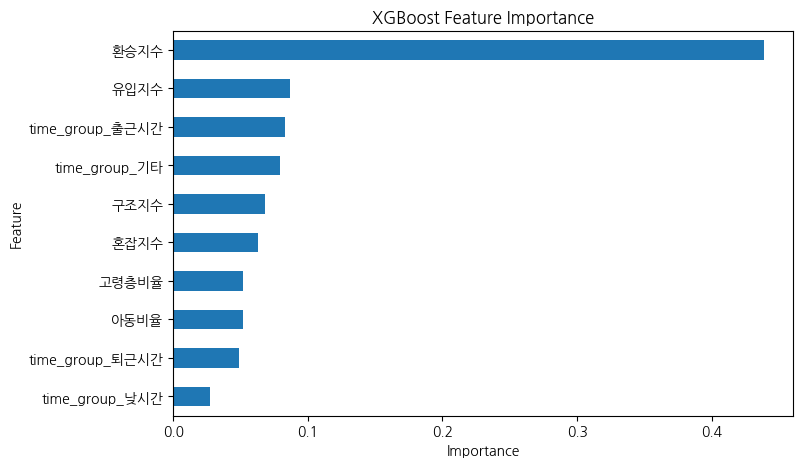

In [35]:
# 변수 중요도 시각화
# XGBoost 모델이 사고발생 예측에 어떤 변수를 중요하게 사용했는지 그래프로 확인

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 변수 중요도 막대그래프
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 해석
# 환승지수가 가장 높은 중요도를 보임
# 이는 환승량과 환승 동선의 복잡성이 사고발생 예측에 높은 설명력을 가진다는 의미

# 유입지수와 출근시간 변수도 높은 중요도를 보임
# 이는 특정 시간대 집중 유입과 승객 흐름이 사고위험 형성에 영향을 줄 가능성을 시사함

# 구조지수와 혼잡지수 역시 주요 변수로 나타나
# 사고위험이 단일 요인보다
# 환승, 유입, 구조, 혼잡, 시간대 요인이 복합적으로 작용한 결과임을 보여줌

# 고령층비율과 아동비율도 일정 수준의 중요도를 보여
# 취약계층 특성을 고려한 맞춤형 안전 대책 필요성을 뒷받침함

# 단, 변수 중요도는 인과관계를 의미하지 않으므로
# "환승이 사고의 직접 원인이다"가 아니라
# "환승 관련 변수가 사고위험 예측에 크게 활용되었다"라고 해석해야 함

# Risk Score 붙이기

In [40]:
# Risk Score 생성
# XGBoost 모델의 사고발생 예측확률을 0~100점 위험도 점수로 변환

# Risk: 사고발생 예측확률, 0~1 사이 값
df_model['Risk'] = xgb_clf.predict_proba(X)[:, 1]

# Risk_Score: 해석하기 쉽도록 100점 만점으로 변환
df_model['Risk_Score'] = df_model['Risk'] * 100

# Risk Score 확인
df_model[['역명_clean', '호선명', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,0.622241,62.224121,0,0
1,동대문,1호선,0.780582,78.058197,0,0
2,동대문,1호선,0.681213,68.121300,0,0
3,동대문,1호선,0.748981,74.898071,0,0
4,동묘앞,1호선,0.369300,36.929951,0,0


In [41]:
# 원본 df에도 Risk Score 붙이기
# df에는 time_group 컬럼이 남아 있으므로 역·호선·시간대별 위험도 확인 가능

df['Risk'] = df_model['Risk']
df['Risk_Score'] = df_model['Risk_Score']

# 역·호선·시간대별 Risk Score 확인
df[['역명_clean', '호선명', 'time_group', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,time_group,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,기타,0.622241,62.224121,0,0
1,동대문,1호선,낮시간,0.780582,78.058197,0,0
2,동대문,1호선,출근시간,0.681213,68.121300,0,0
3,동대문,1호선,퇴근시간,0.748981,74.898071,0,0
4,동묘앞,1호선,기타,0.369300,36.929951,0,0


In [42]:
# 역·호선·시간대별 위험도 순위 생성
# 같은 역/호선/시간대 조합이 여러 행에 존재할 수 있으므로 평균 Risk Score로 집계
# 사고수는 실제 사고 발생 규모 확인을 위해 합계로 집계

top_risk_station_time = (
    df
    .groupby(['역명_clean', '호선명', 'time_group'], as_index=False)
    .agg(
        Risk_Score=('Risk_Score', 'mean'),
        Risk=('Risk', 'mean'),
        사고수=('사고수', 'sum'),
        사고발생=('사고발생', 'max'),
        혼잡지수=('혼잡지수', 'mean'),
        유입지수=('유입지수', 'mean'),
        구조지수=('구조지수', 'mean'),
        환승지수=('환승지수', 'mean')
    )
    .sort_values('Risk_Score', ascending=False)
)

# 위험도 상위 20개 역·호선·시간대 확인
top_risk_station_time.head(20)

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수
519,사당,2호선,퇴근시간,89.612411,0.896124,11,1,2.543994e-01,0.238396,0.357143,0.597375
517,사당,2호선,낮시간,89.576988,0.895770,12,1,2.463075e-01,0.225071,0.357143,0.597375
521,사당,4호선,낮시간,89.482674,0.894827,8,1,1.584908e-01,0.353410,0.267857,0.597375
1009,종로3가,1호선,낮시간,89.417564,0.894176,4,1,2.200805e-01,0.354844,0.607143,0.604816
701,신도림,2호선,낮시간,89.229874,0.892299,10,1,3.064714e-01,0.203331,0.267857,1.000000
85,고속터미널,7호선,낮시간,88.969872,0.889699,13,1,1.237434e-01,0.225579,0.678571,0.699515
523,사당,4호선,퇴근시간,88.902618,0.889026,10,1,1.373551e-01,0.377957,0.267857,0.597375
703,신도림,2호선,퇴근시간,88.441673,0.884417,17,1,2.792300e-01,0.256430,0.267857,1.000000
1101,충무로,4호선,낮시간,88.061241,0.880612,7,1,1.892837e-01,0.232864,0.696429,0.528398
965,잠실,2호선,낮시간,87.898598,0.878986,7,1,5.137562e-01,0.509654,0.535714,0.397087


In [43]:
print(search.best_params_)
print(xgb_clf)

{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [44]:
# 위험 유형 분류
# 각 역·호선·시간대 조합에서 가장 높은 지수를 기준으로 위험 유형을 부여
# 예: 혼잡지수가 가장 높으면 혼잡형, 구조지수가 가장 높으면 구조형

def classify_risk_type(row):
    values = {
        '혼잡형': row['혼잡지수'],
        '유입형': row['유입지수'],
        '구조형': row['구조지수'],
        '환승형': row['환승지수']
    }
    return max(values, key=values.get)

top_risk_station_time['위험유형'] = top_risk_station_time.apply(classify_risk_type, axis=1)

# 위험도 상위 20개 역·호선·시간대와 위험유형 확인
top_risk_station_time.head(20)

# 시간 기준 모델의 위험도 상위 역·시간대 결과 해석
# Risk Score 상위 20개 구간은 모두 사고발생=1로 나타남
# 즉, 모델이 위험도가 높다고 판단한 역·호선·시간대가 실제 사고 발생 구간과 잘 대응됨

# 상위 위험 구간 예시
# 사당 2호선 퇴근시간: Risk Score 89.61, 사고수 11건
# 사당 2호선 낮시간: Risk Score 89.58, 사고수 12건
# 사당 4호선 낮시간: Risk Score 89.48, 사고수 8건
# 종로3가 1호선 낮시간: Risk Score 89.42, 사고수 4건
# 신도림 2호선 낮시간: Risk Score 89.23, 사고수 10건
# 고속터미널 7호선 낮시간: Risk Score 88.97, 사고수 13건

# 위험유형 해석
# 상위 위험 구간은 환승형과 구조형이 다수로 나타남
# 사당, 신도림, 고속터미널 등은 환승지수가 높아 환승형으로 분류됨
# 충무로, 서울, 종로3가 등은 구조지수가 높아 구조형으로 분류됨

# 일부 구간은 유입형으로 분류됨
# 예: 잠실 2호선 퇴근시간
# 이는 특정 역·시간대에서 외부 유입 인구 규모가 위험도 형성에 크게 작용할 수 있음을 보여줌

# 결론
# 시간 기준으로 학습·평가한 XGBoost 기반 Risk Score는
# 실제 사고가 발생한 역·시간대를 상위 위험구간으로 효과적으로 선별함
# 따라서 본 모델은 역별·시간대별 안전관리 우선순위 선정과
# 위험유형별 맞춤형 대응 전략 수립에 활용할 수 있음

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수,위험유형
519,사당,2호선,퇴근시간,89.612411,0.896124,11,1,2.543994e-01,0.238396,0.357143,0.597375,환승형
517,사당,2호선,낮시간,89.576988,0.895770,12,1,2.463075e-01,0.225071,0.357143,0.597375,환승형
521,사당,4호선,낮시간,89.482674,0.894827,8,1,1.584908e-01,0.353410,0.267857,0.597375,환승형
1009,종로3가,1호선,낮시간,89.417564,0.894176,4,1,2.200805e-01,0.354844,0.607143,0.604816,구조형
701,신도림,2호선,낮시간,89.229874,0.892299,10,1,3.064714e-01,0.203331,0.267857,1.000000,환승형
85,고속터미널,7호선,낮시간,88.969872,0.889699,13,1,1.237434e-01,0.225579,0.678571,0.699515,환승형
523,사당,4호선,퇴근시간,88.902618,0.889026,10,1,1.373551e-01,0.377957,0.267857,0.597375,환승형
703,신도림,2호선,퇴근시간,88.441673,0.884417,17,1,2.792300e-01,0.256430,0.267857,1.000000,환승형
1101,충무로,4호선,낮시간,88.061241,0.880612,7,1,1.892837e-01,0.232864,0.696429,0.528398,구조형
965,잠실,2호선,낮시간,87.898598,0.878986,7,1,5.137562e-01,0.509654,0.535714,0.397087,구조형
